### Project Overview: Analyzing Cancer Healthcare Data

This project analyzes healthcare expenditure data with cancer to understand utilization, costs, and financial burdens. It involves data loading, cleaning, transformation, and comprehensive statistical summaries to gain insights into this critical demographic.

### Section 1: **Initial Setup** - Importing Necessary Libraries

To begin our data analysis, we import several fundamental Python libraries:

*   **`numpy` (as `np`)**: For numerical operations and array handling.
*   **`pandas` (as `pd`)**: For data manipulation and analysis, especially with DataFrames.
*   **`matplotlib.pyplot` (as `plt`)**: For creating static, animated, and interactive visualizations.
*   **`seaborn` (as `sns`)**: For high-level interfaces to draw attractive and informative statistical graphics.
*   **`sklearn.preprocessing.StandardScaler`**: For standardizing features (used later in the workflow).

These imports ensure we have all necessary tools for data handling, analysis, and visualization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Section 2: **Data Loading**

We load the raw healthcare data from Excel files into Pandas DataFrames. Displaying the first few rows (`df.head()`) provides a quick overview of the data's structure and values, essential for understanding its format.

In [ ]:
col_name = ['DUID', 'AGE', 'TTLP', 'INSCOV', 'RTHLTH', 'TOTEXP', 'TOTSLF', 'TOTPRV',
       'POVCAT', 'FAMINC', 'OBTOTV', 'IPDIS', 'RXTOT']

In [ ]:
def getCancerData (file_path, sheet_name1, sheet_name2):

  # Construct the full file path
  file_path = '/content/sample_data/'+ file_path

  # Load the base dataframe and assign predefined column names
  df_base = pd.read_excel(file_path, sheet_name = sheet_name1)
  df_base.columns = col_name

  # Load the cancer-specific dataframe
  df_cancer = pd.read_excel(file_path, sheet_name = sheet_name2)

  # Perform a left merge to combine the base and cancer dataframes.
  # 'indicator=True' adds a column indicating the source of each row (left_only, right_only, both).
  # 'reset_index(drop=True)' resets the index after merging.
  merged_df = pd.merge(df_base, df_cancer, on='DUID', how='left', indicator=True).reset_index(drop=True)

  # Create 'Cancer_Indicator' column: 'Yes' if DUID is found in both sheets, 'No' otherwise.
  merged_df['Cancer_Indicator'] = np.where(merged_df['_merge'] == 'both', 'Yes', 'No')

  # Create 'Age_Indicator' column: 'Yes' if AGE is less than 22, 'No' otherwise.
  merged_df['Age_Indicator'] = np.where(merged_df['AGE'] < 22, 'Yes', 'No')

  # Ensure the 'AGE' column contains absolute values.
  merged_df['AGE'] = np.abs(merged_df['AGE'])

  # Drop the temporary '_merge' column as it's no longer needed after creating 'Cancer_Indicator'.
  df = merged_df.drop(columns=['_merge'])

  # Remove duplicate rows to ensure uniqueness in the dataset.
  df.drop_duplicates(inplace=True)

  # Reset the DataFrame index after dropping duplicates, making sure the index is continuous.
  df = df.reset_index(drop=True)

  # Return the processed DataFrame.
  return df

In [ ]:
df_2019 = getCancerData('2019_data.xlsx','Sheet1', 'Sheet2')
#df_2019.columns = col_name
df_2019['Year'] = '2019'

In [ ]:
df_2020 = getCancerData('2020_data.xlsx','Sheet1', 'Sheet2')
#df_2020.columns = col_name
df_2020['Year'] = '2020'

In [ ]:
df_2021 = getCancerData('2021_data.xlsx','Sheet1', 'Sheet2')
#df_2021.columns = col_name
df_2021['Year'] = '2021'

In [ ]:
df_2022 = getCancerData('2022_data.xlsx','Sheet1', 'Sheet2')
#df_2022.columns = col_name
df_2022['Year'] = '2022'

In [ ]:
df_2023 = getCancerData('2023_data.xlsx','Sheet4', 'Sheet2')
#df_2023.columns = col_name
df_2023['Year'] = '2023'

In [ ]:
master_df = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023], ignore_index=True)

# Display the head of the combined DataFrame
print("Combined DataFrame Head:")
display(master_df.head())

# Display the shape of the combined DataFrame
print(f"\nCombined DataFrame Shape: {master_df.shape}")

Combined DataFrame Head:


,DUID,AGE,TTLP,INSCOV,RTHLTH,TOTEXP,TOTSLF,TOTPRV,POVCAT,FAMINC,OBTOTV,IPDIS,RXTOT,Cancer_Indicator,Age_Indicator,Year
0,2320002,31,40000,1,1,0,0,0,4,40000,0,0,0,Yes,No,2019
1,2320002,41,40000,1,2,54,0,54,4,40000,1,0,0,Yes,No,2019
2,2320002,15,0,1,3,7827,320,7507,4,40000,5,1,0,Yes,Yes,2019
3,2320005,71,0,2,3,615,18,0,1,0,2,0,2,Yes,No,2019
4,2320005,82,0,2,4,2452,459,0,1,0,1,0,12,Yes,No,2019



Combined DataFrame Shape: (125851, 16)


In [ ]:
master_df= master_df[master_df['Cancer_Indicator'] == 'Yes'].reset_index(drop=True)

# Display the head of the Cancer DataFrame
print("Cancer DataFrame Head:")
display(master_df.head())

# Display the shape of the  Cancer DataFrame
print(f"\ Cancer DataFrame Shape: {master_df.shape}")

Cancer DataFrame Head:


<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_16560/2252429080.py:8: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Cancer DataFrame Shape: {master_df.shape}")


,DUID,AGE,TTLP,INSCOV,RTHLTH,TOTEXP,TOTSLF,TOTPRV,POVCAT,FAMINC,OBTOTV,IPDIS,RXTOT,Cancer_Indicator,Age_Indicator,Year
0,2320002,31,40000,1,1,0,0,0,4,40000,0,0,0,Yes,No,2019
1,2320002,41,40000,1,2,54,0,54,4,40000,1,0,0,Yes,No,2019
2,2320002,15,0,1,3,7827,320,7507,4,40000,5,1,0,Yes,Yes,2019
3,2320005,71,0,2,3,615,18,0,1,0,2,0,2,Yes,No,2019
4,2320005,82,0,2,4,2452,459,0,1,0,1,0,12,Yes,No,2019


\ Cancer DataFrame Shape: (114511, 16)


### Data Dictionary and Suggested Renaming

Here's a summary of the provided columns, including suggested new names for clarity and their categorical values or notes.

| Original Column Name | Suggested New Name         | Description                                                          | Categorical Values / Notes                                                                                                                                                                                                 |
| :------------------- | :------------------------- | :------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `AGE`                | `age`                      | Age of the individual.                                               | Filter for ages 0 to 18.                                                                                                                                                                                               |
| `DUID`               | `medical_condition_id`     | Medical Conditions File Identifier (HC-249).                         | Unique identifier.                                                                                                                                                                                                     |
| `TTLP`               | `individual_income_dollars`| Total income in dollars.                                             |                                                                                                                                                                                                                          |
| `INSCOV`             | `insurance_status`         | Health insurance status for the full year.                           | 1: Any Private Insurance<br>2: Public Only Insurance<br>3: Uninsured                                                                                                                                                 |
| `RTHLTH`             | `perceived_health_status`  | Perceived health status (helps show the severity of the illness).    | 1: Excellent<br>2: Very Good<br>3: Good<br>4: Fair<br>5: Poor                                                                                                                                                           |
| `TOTEXP`             | `total_healthcare_exp`     | Total healthcare expenditures for the individual.                    |                                                                                                                                                                                                                          |
| `TOTSLF`             | `total_oop_payments`       | Total Out-of-Pocket (OOP) payments made by the family.               |                                                                                                                                                                                                                          |
| `TOTPRV`             | `amount_paid_private_ins`  | Amount paid by private insurance.                                    |                                                                                                                                                                                                                          |
| `POVCAT`             | `poverty_status`           | Poverty status (key indicator for financial hardship).               | 1: Poor<br>2: Near Poor<br>3: Low Income<br>4: Middle Income<br>5: High Income                                                                                                                                                                                                                          |
| `FAMINC`             | `family_income_dollars`    | Total family income in dollars.                                      |                                                                                                                                                                                                                          |
| `IPDIS`              | `hospital_discharge_nights`| Total number of hospital discharge nights.                           |                                                                                                                                                                                                                          |
| `RXTOT`              | `num_prescribed_medicines` | Total number of prescribed medicines filled.                         |                                                                                                                                                                                                                          |
| `OBTOTV`             | `num_office_visits`        | Total number of office-based visits.                                 |                                                                                                                                                                                                                          |
| `N/A`                | `income_poverty_percent`   | Family income as a percentage of the poverty line (string ranges).   | 1: <100%<br>2: 100%-124%<br>3: 125%-199%<br>4: 200%-399%<br>5: 400%+ |
| `N/A`                | `Cancer_Indicator`         | Indicates if the individual has cancer.                              | 'Yes' or 'No'                                                                                                                                                                                                          |
| `N/A`                | `Age_Indicator`            | Indicates if the individual is under 21 years old.                   | 'Yes' or 'No'                                                                                                                                                                                                          |
| `N/A`                | `Year`                     | The year the data pertains to.                                       | 2019, 2020, 2021, 2022, 2023                                                                                                                                                                                           |

### Section 3: **Data Wrangling** - Column Renaming for Clarity and Consistency

To enhance readability and maintain consistency throughout the analysis, we rename several columns using a predefined mapping. This step transforms cryptic or abbreviated original column names into more descriptive and understandable ones. For instance, `AGE23X` becomes `age`, `DUID` becomes `medical_condition_id`, and `TTLP23X` becomes `individual_income_dollars`. This makes the DataFrame easier to work with and interpret.

In [ ]:
df = master_df.copy()
df = df.drop(columns=['Cancer_Indicator', 'Age_Indicator'])
print("DataFrame for further analysis (df) Head:")
display(df.head())
print(f"\nDataFrame (df) Shape: {df.shape}")

DataFrame for further analysis (df) Head:


,DUID,AGE,TTLP,INSCOV,RTHLTH,TOTEXP,TOTSLF,TOTPRV,POVCAT,FAMINC,OBTOTV,IPDIS,RXTOT,Year
0,2320002,31,40000,1,1,0,0,0,4,40000,0,0,0,2019
1,2320002,41,40000,1,2,54,0,54,4,40000,1,0,0,2019
2,2320002,15,0,1,3,7827,320,7507,4,40000,5,1,0,2019
3,2320005,71,0,2,3,615,18,0,1,0,2,0,2,2019
4,2320005,82,0,2,4,2452,459,0,1,0,1,0,12,2019



DataFrame (df) Shape: (114511, 14)


In [ ]:
column_rename_map = {
    'AGE': 'age',
    'DUID': 'medical_condition_id',
    'TTLP': 'individual_income_dollars',
    'INSCOV': 'insurance_status',
    'RTHLTH': 'perceived_health_status',
    'TOTEXP': 'total_healthcare_exp',
    'TOTSLF': 'total_oop_payments',
    'TOTPRV': 'amount_paid_private_ins',
    'POVCAT': 'poverty_status',
    'FAMINC': 'family_income_dollars',
    'IPDIS': 'hospital_discharge_nights',
    'RXTOT': 'num_prescribed_medicines',
    'OBTOTV': 'num_office_visits',
    'Year':'Year'
}

df = df.rename(columns=column_rename_map)
display(df.head())

,medical_condition_id,age,individual_income_dollars,insurance_status,perceived_health_status,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,poverty_status,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,Year
0,2320002,31,40000,1,1,0,0,0,4,40000,0,0,0,2019
1,2320002,41,40000,1,2,54,0,54,4,40000,1,0,0,2019
2,2320002,15,0,1,3,7827,320,7507,4,40000,5,1,0,2019
3,2320005,71,0,2,3,615,18,0,1,0,2,0,2,2019
4,2320005,82,0,2,4,2452,459,0,1,0,1,0,12,2019


In [ ]:
print(f"Minimum age: {df['age'].min()}")
print(f"Maximum age: {df['age'].max()}")

Minimum age: 0
Maximum age: 85


In [ ]:
# Calculate Out-of-Pocket percentage of Family Income
df['oop_as_percent_of_family_income'] = (df['total_oop_payments'] / df['family_income_dollars']) * 100

# Create 'Financial_burden' column based on the updated condition
df['Financial_burden'] = df.apply(lambda row: 'yes' if row['family_income_dollars'] != 0 and row['oop_as_percent_of_family_income'] > 9 else 'no', axis=1)

# Filter data only with 'yes' for financial burden
df_burden_yes = df[df['Financial_burden'] == 'yes'].copy()


print("DataFrame with 'oop_as_percent_of_family_income' and 'Financial_burden' columns:")
#display(df.head())

print("\nFiltered DataFrame (Financial_burden = 'yes') Head:")
display(df_burden_yes.head())

print(f"\nShape of the filtered DataFrame: {df_burden_yes.shape}")

DataFrame with 'oop_as_percent_of_family_income' and 'Financial_burden' columns:

Filtered DataFrame (Financial_burden = 'yes') Head:


,medical_condition_id,age,individual_income_dollars,insurance_status,perceived_health_status,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,poverty_status,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,Year,oop_as_percent_of_family_income,Financial_burden
8,2320008,33,32058,1,2,14206,6164,8043,4,32058,7,0,3,2019,19.227650,yes
26,2320025,85,17130,1,5,57838,4189,2072,4,34260,14,3,14,2019,12.227087,yes
58,2320041,28,35000,1,3,7296,5738,1557,4,35000,21,0,13,2019,16.394286,yes
69,2320050,37,18000,1,3,9681,2627,6647,3,18000,3,0,41,2019,14.594444,yes
76,2320055,3,0,1,3,11549,4879,6670,3,38000,4,1,2,2019,12.839474,yes



Shape of the filtered DataFrame: (4995, 16)


### Section 4: **Data Wrangling** - Adjusting Categorical Values for Better Interpretability

Many datasets use numerical codes to represent categorical variables. To make these columns more human-readable and facilitate easier analysis and reporting, we map these numerical codes to descriptive string labels. This section specifically addresses `insurance_status`, `perceived_health_status`, and `poverty_status`, transforming them from numbers to meaningful categories like 'Any Private Insurance', 'Excellent', or 'Poor'. Additionally, a new column, `income_poverty_percent`, is created to represent income as a percentage of the poverty line, using string ranges for clarity.

In [ ]:
insurance_status_map = {
    1: 'Any Private Insurance',
    2: 'Public Only Insurance',
    3: 'Uninsured'
}
df['insurance_status'] = df['insurance_status'].map(insurance_status_map)

perceived_health_status_map = {
    1: 'Excellent',
    2: 'Very Good',
    3: 'Good',
    4: 'Fair',
    5: 'Poor'
}
df['perceived_health_status'] = df['perceived_health_status'].map(perceived_health_status_map)

# Map for the new 'income_poverty_percent' column to contain string ranges
income_poverty_percent_map = {
    1: '<100%',
    2: '100%-124%',
    3: '125%-199%',
    4: '200%-399%',
    5: '400%+'
}
df['income_poverty_percent'] = df['poverty_status'].map(income_poverty_percent_map)

# Updated poverty_status_map with simpler labels
poverty_status_map = {
    1: 'Poor',
    2: 'Near Poor',
    3: 'Low Income',
    4: 'Middle Income',
    5: 'High Income'
}
df['poverty_status'] = df['poverty_status'].map(poverty_status_map)

display(df.head())

,medical_condition_id,age,individual_income_dollars,insurance_status,perceived_health_status,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,poverty_status,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,Year,oop_as_percent_of_family_income,Financial_burden,income_poverty_percent
0,2320002,31,40000,Any Private Insurance,Excellent,0,0,0,Middle Income,40000,0,0,0,2019,0.0,no,200%-399%
1,2320002,41,40000,Any Private Insurance,Very Good,54,0,54,Middle Income,40000,1,0,0,2019,0.0,no,200%-399%
2,2320002,15,0,Any Private Insurance,Good,7827,320,7507,Middle Income,40000,5,1,0,2019,0.8,no,200%-399%
3,2320005,71,0,Public Only Insurance,Good,615,18,0,Poor,0,2,0,2,2019,inf,no,<100%
4,2320005,82,0,Public Only Insurance,Fair,2452,459,0,Poor,0,1,0,12,2019,inf,no,<100%


In [ ]:
bins = [-1, 3, 12, 18, 64, np.inf]
labels = ['Baby Toddler', 'Kid', 'Teenage', 'Adult', 'Old']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

print("DataFrame head with new 'age_group' column:")
display(df.head())

print("\nValue counts for 'age_group':")
display(df['age_group'].value_counts())

DataFrame head with new 'age_group' column:


,medical_condition_id,age,individual_income_dollars,insurance_status,perceived_health_status,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,poverty_status,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,Year,oop_as_percent_of_family_income,Financial_burden,income_poverty_percent,age_group
0,2320002,31,40000,Any Private Insurance,Excellent,0,0,0,Middle Income,40000,0,0,0,2019,0.0,no,200%-399%,Adult
1,2320002,41,40000,Any Private Insurance,Very Good,54,0,54,Middle Income,40000,1,0,0,2019,0.0,no,200%-399%,Adult
2,2320002,15,0,Any Private Insurance,Good,7827,320,7507,Middle Income,40000,5,1,0,2019,0.8,no,200%-399%,Teenage
3,2320005,71,0,Public Only Insurance,Good,615,18,0,Poor,0,2,0,2,2019,inf,no,<100%,Old
4,2320005,82,0,Public Only Insurance,Fair,2452,459,0,Poor,0,1,0,12,2019,inf,no,<100%,Old



Value counts for 'age_group':


,count
age_group,
Adult,61666
Old,26133
Kid,12093
Teenage,8356
Baby Toddler,6263


In [ ]:
df = df.drop(columns=['individual_income_dollars', 'oop_as_percent_of_family_income'])
display(df.head())

,medical_condition_id,age,insurance_status,perceived_health_status,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,poverty_status,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,Year,Financial_burden,income_poverty_percent,age_group
0,2320002,31,Any Private Insurance,Excellent,0,0,0,Middle Income,40000,0,0,0,2019,no,200%-399%,Adult
1,2320002,41,Any Private Insurance,Very Good,54,0,54,Middle Income,40000,1,0,0,2019,no,200%-399%,Adult
2,2320002,15,Any Private Insurance,Good,7827,320,7507,Middle Income,40000,5,1,0,2019,no,200%-399%,Teenage
3,2320005,71,Public Only Insurance,Good,615,18,0,Poor,0,2,0,2,2019,no,<100%,Old
4,2320005,82,Public Only Insurance,Fair,2452,459,0,Poor,0,1,0,12,2019,no,<100%,Old


### Section 5: **Exploratory Data Analysis (EDA)** - Statistical Summary of Numerical Columns

To understand the central tendency, dispersion, and missingness of our quantitative data, we generate a comprehensive statistical summary for all numerical columns. This summary includes:

*   **`count`**: The number of non-null observations.
*   **`mean`**: The average value.
*   **`std`**: The standard deviation, indicating the spread of data.
*   **`min`** and **`max`**: The minimum and maximum values.
*   **`25%`, `50%` (median), `75%`**: The quartiles, giving insight into data distribution.
*   **`num_zeros`**: A custom metric indicating how many values in each column are exactly zero, which can be important for understanding sparse data or specific conditions (e.g., zero income, zero medical visits).
*   **`num_nulls`**: The count of missing values, highlighting data completeness issues.

The `medical_condition_id` column is excluded from this summary as it's an identifier, not a quantitative measure for statistical analysis. All numerical results are rounded to two decimal places for easier reading.

In [ ]:
import numpy as np

def get_numerical_summary(df, numerical_cols):
    summary = df[numerical_cols].describe().transpose()
    summary['num_zeros'] = (df[numerical_cols] == 0).sum()
    summary['num_nulls'] = df[numerical_cols].isnull().sum()
    return summary

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Remove 'medical_condition_id' from the list of numerical columns for the summary
numerical_cols_filtered = [col for col in numerical_cols if col != 'medical_condition_id']

print("Statistical Summary of Numerical Columns with Zero Counts and Null Counts:")
summary_df = get_numerical_summary(df, numerical_cols_filtered)
display(summary_df.round(2))

Statistical Summary of Numerical Columns with Zero Counts and Null Counts:


,count,mean,std,min,25%,50%,75%,max,num_zeros,num_nulls
age,114511.0,42.11,24.47,0.0,20.0,43.0,63.0,85.0,968,0
total_healthcare_exp,114511.0,7930.36,23702.42,0.0,364.0,1766.0,6640.0,2187290.0,12797,0
total_oop_payments,114511.0,942.10,3851.49,0.0,0.0,174.0,810.0,598396.0,29200,0
amount_paid_private_ins,114511.0,2790.98,13359.20,0.0,0.0,158.0,1379.0,779136.0,48343,0
family_income_dollars,114511.0,86866.39,81739.78,-635454.0,29688.0,63800.0,119995.0,787696.0,3325,0
num_office_visits,114511.0,7.29,14.17,0.0,1.0,3.0,8.0,502.0,25074,0
hospital_discharge_nights,114511.0,0.10,0.41,0.0,0.0,0.0,0.0,12.0,105847,0
num_prescribed_medicines,114511.0,11.36,20.64,0.0,0.0,3.0,14.0,638.0,39762,0


In [ ]:
df['family_income_dollars'] = np.abs(df['family_income_dollars'])
display(df.head())

,medical_condition_id,age,insurance_status,perceived_health_status,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,poverty_status,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,Year,Financial_burden,income_poverty_percent,age_group
0,2320002,31,Any Private Insurance,Excellent,0,0,0,Middle Income,40000,0,0,0,2019,no,200%-399%,Adult
1,2320002,41,Any Private Insurance,Very Good,54,0,54,Middle Income,40000,1,0,0,2019,no,200%-399%,Adult
2,2320002,15,Any Private Insurance,Good,7827,320,7507,Middle Income,40000,5,1,0,2019,no,200%-399%,Teenage
3,2320005,71,Public Only Insurance,Good,615,18,0,Poor,0,2,0,2,2019,no,<100%,Old
4,2320005,82,Public Only Insurance,Fair,2452,459,0,Poor,0,1,0,12,2019,no,<100%,Old


### Section 6: **Exploratory Data Analysis (EDA)** - Statistical Summary of Categorical Columns

For our categorical features, a different type of summary is required to understand their distribution and characteristics. This section generates a summary that includes:

*   **`count`**: The total number of non-null entries.
*   **`unique_count`**: The number of distinct categories within the column.
*   **`top`**: The most frequently occurring category.
*   **`freq`**: The frequency (count) of the top category.
*   **`num_nulls`**: The count of missing values for the categorical column.
*   **`unique_values`**: A complete list of all distinct categories present in the column.

This summary helps us quickly grasp the diversity and distribution of values across our categorical variables, which is vital for understanding their potential impact on the analysis.

In [ ]:
def get_categorical_summary(df, categorical_cols):
    summary = pd.DataFrame(columns=['count', 'unique_count', 'top', 'freq', 'num_nulls', 'unique_values'])
    for col in categorical_cols:
        series = df[col]
        summary.loc[col] = [
            series.count(),
            series.nunique(),
            series.mode()[0] if not series.mode().empty else np.nan, # Handle empty mode for all-nan series
            series.value_counts().max() if not series.value_counts().empty else np.nan,
            series.isnull().sum(),
            series.unique().tolist() # Store unique values as a list
        ]
    return summary

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Statistical Summary of Categorical Columns:")
categorical_summary_df = get_categorical_summary(df, categorical_cols)
display(categorical_summary_df)

Statistical Summary of Categorical Columns:


,count,unique_count,top,freq,num_nulls,unique_values
insurance_status,114511,3,Any Private Insurance,67726,0,"[Any Private Insurance, Public Only Insurance,..."
perceived_health_status,111933,5,Very Good,35252,2578,"[Excellent, Very Good, Good, Fair, Poor, nan]"
poverty_status,114511,5,High Income,42855,0,"[Middle Income, Poor, High Income, Low Income,..."
Year,114511,5,2019,26437,0,"[2019, 2020, 2021, 2022, 2023]"
Financial_burden,114511,2,no,109516,0,"[no, yes]"
income_poverty_percent,114511,5,400%+,42855,0,"[200%-399%, <100%, 400%+, 125%-199%, 100%-124%]"
age_group,114511,5,Adult,61666,0,"[Adult, Teenage, Old, Kid, Baby Toddler]"


In [ ]:
for index, row in categorical_summary_df.iterrows():
    print(f"\nUnique '{index}': {row['unique_values']}")


Unique 'insurance_status': ['Any Private Insurance', 'Public Only Insurance', 'Uninsured']

Unique 'perceived_health_status': ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor', nan]

Unique 'poverty_status': ['Middle Income', 'Poor', 'High Income', 'Low Income', 'Near Poor']

Unique 'Year': ['2019', '2020', '2021', '2022', '2023']

Unique 'Financial_burden': ['no', 'yes']

Unique 'income_poverty_percent': ['200%-399%', '<100%', '400%+', '125%-199%', '100%-124%']

Unique 'age_group': ['Adult', 'Teenage', 'Old', 'Kid', 'Baby Toddler']


In [ ]:
df.shape

(114511, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114511 entries, 0 to 114510
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   medical_condition_id       114511 non-null  int64   
 1   age                        114511 non-null  int64   
 2   insurance_status           114511 non-null  object  
 3   perceived_health_status    111933 non-null  object  
 4   total_healthcare_exp       114511 non-null  int64   
 5   total_oop_payments         114511 non-null  int64   
 6   amount_paid_private_ins    114511 non-null  int64   
 7   poverty_status             114511 non-null  object  
 8   family_income_dollars      114511 non-null  int64   
 9   num_office_visits          114511 non-null  int64   
 10  hospital_discharge_nights  114511 non-null  int64   
 11  num_prescribed_medicines   114511 non-null  int64   
 12  Year                       114511 non-null  object  
 13  Financial_burd

### Section 7:Chart
Correlation Heatmap

This heatmap visually represents the pairwise correlation coefficients between all numerical variables in the `df` DataFrame. The color intensity and the value (annotated on each cell) indicate the strength and direction of the linear relationship between two variables.

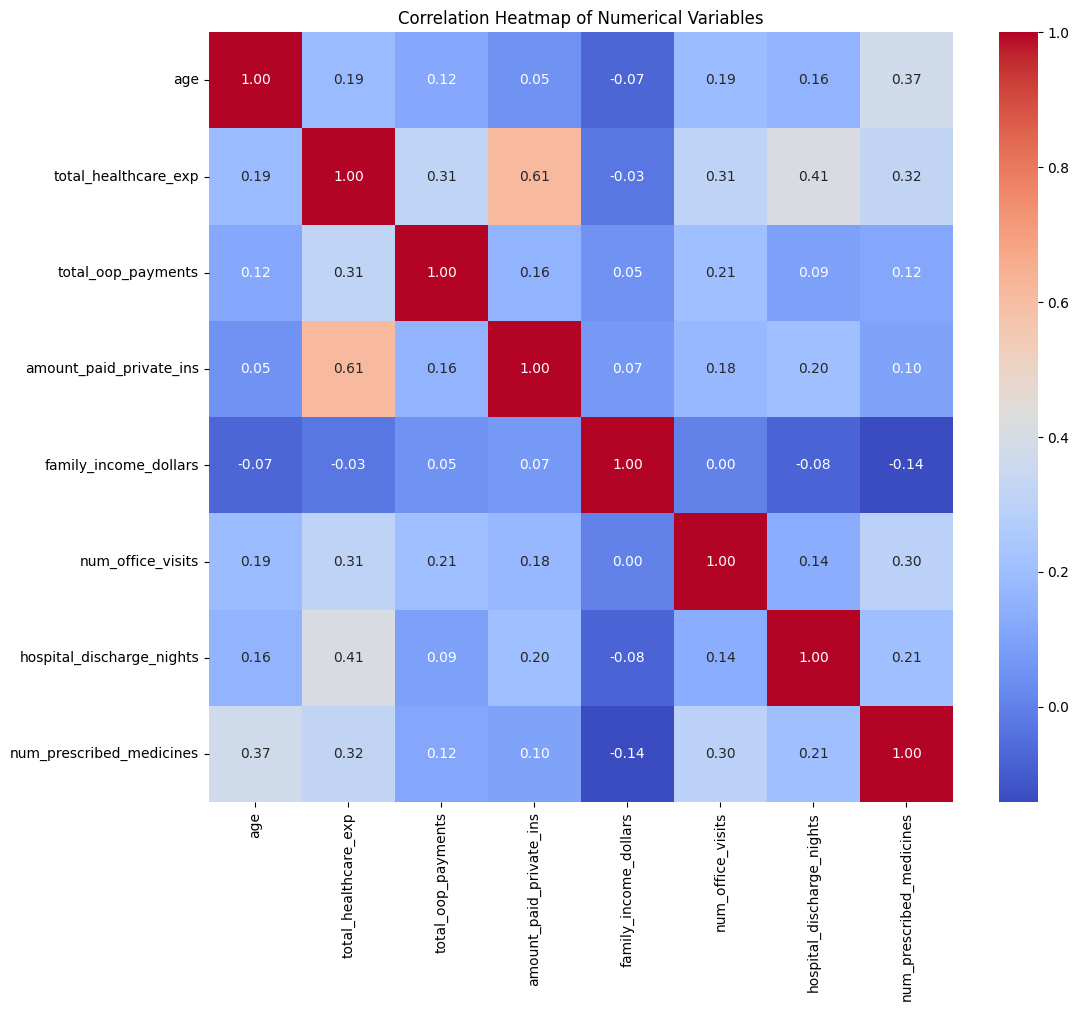

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=np.number).drop(columns=['medical_condition_id']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()


#### Distribution of Age (Histogram)

This histogram displays the distribution of the `age` variable. It shows how many individuals fall into different age bins, providing a view of the age demographics within the dataset.

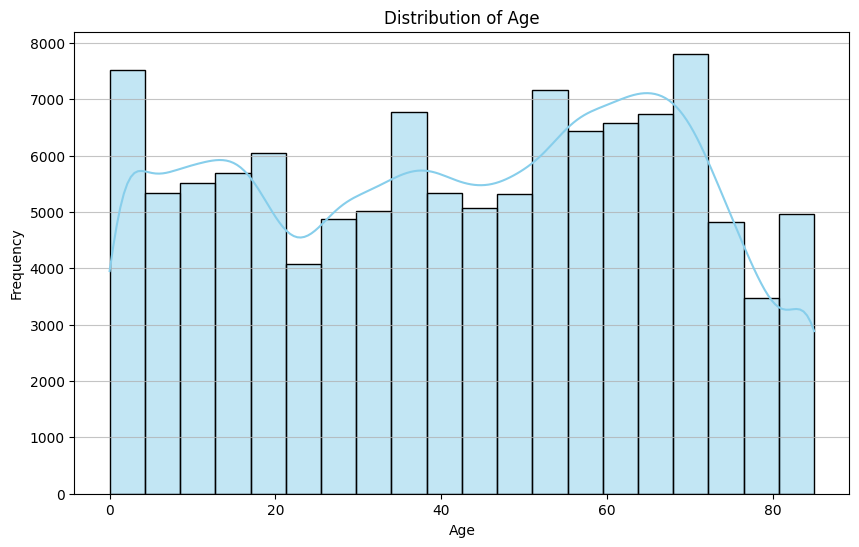

In [ ]:
# Histogram of Age
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Distribution of Family Income (Dollars) (Histogram)

This histogram illustrates the distribution of `family_income_dollars`. Similar to the age histogram, it shows the frequency of different family income levels.

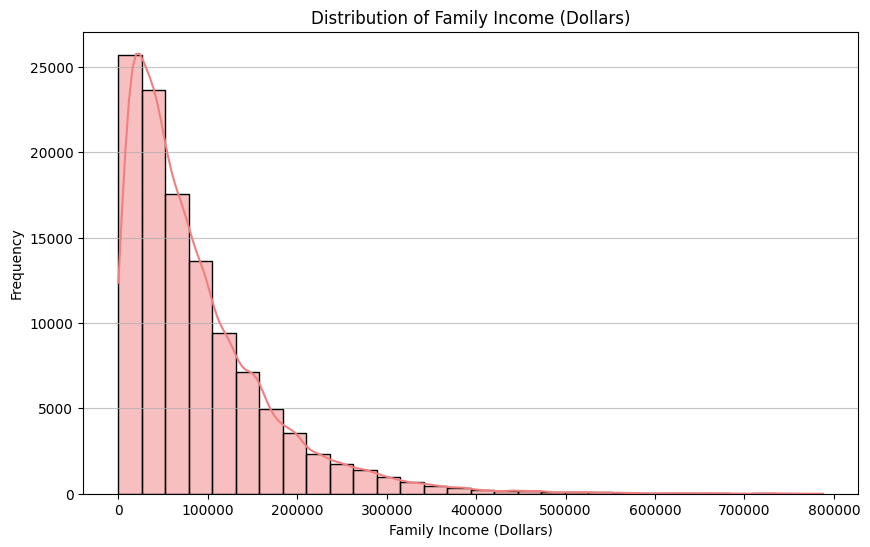

In [ ]:
# Histogram of Family Income
plt.figure(figsize=(10, 6))
sns.histplot(df['family_income_dollars'], bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Family Income (Dollars)')
plt.xlabel('Family Income (Dollars)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Family Income vs. Total Out-of-Pocket Payments (Scatter Plot)

This scatter plot visualizes the relationship between `family_income_dollars` (on the x-axis) and `total_oop_payments` (on the y-axis). Both axes are set to a logarithmic scale (`xscale='log'`, `yscale='log'`) to better handle the wide range and skewed nature of financial data, making patterns more discernible.

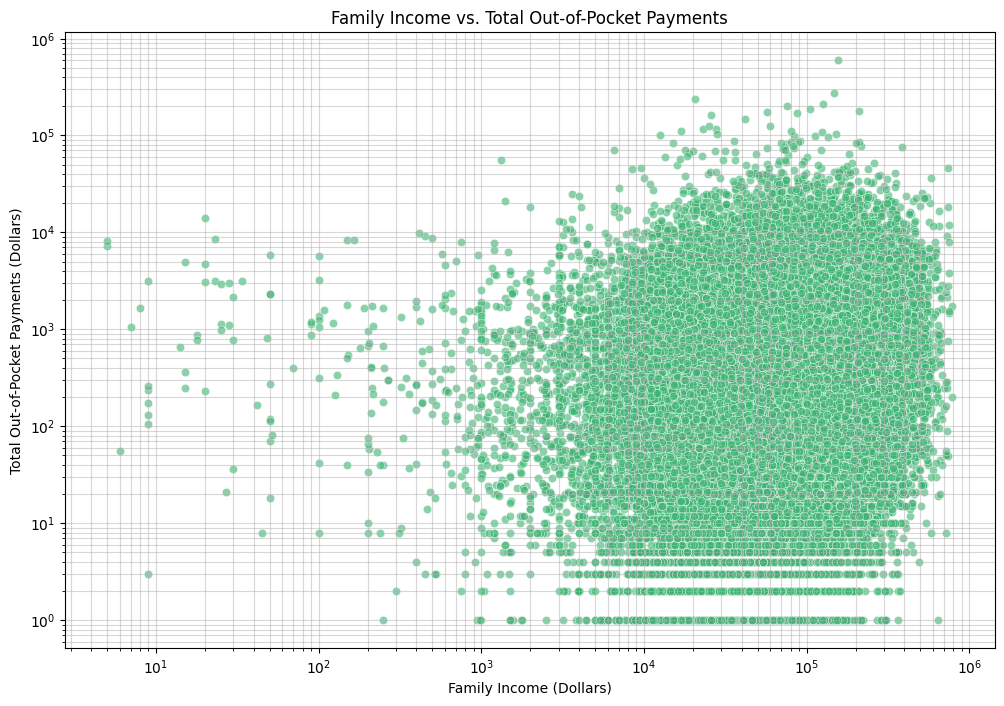

In [ ]:
# Scatter Plot: Family Income vs. Total Out-of-Pocket Payments
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='family_income_dollars', y='total_oop_payments', alpha=0.6, color='mediumseagreen')
plt.title('Family Income vs. Total Out-of-Pocket Payments')
plt.xlabel('Family Income (Dollars)')
plt.ylabel('Total Out-of-Pocket Payments (Dollars)')
plt.xscale('log') # Use log scale for better visualization of skewed data
plt.yscale('log') # Use log scale for better visualization of skewed data
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

####Distribution of Financial Burden (Bar Chart)

This count plot shows the overall distribution of the `Financial_burden` variable, displaying the number of individuals categorized as having 'yes' or 'no' financial burden.

/tmp/ipykernel_16560/3899062683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Financial_burden', palette='viridis')


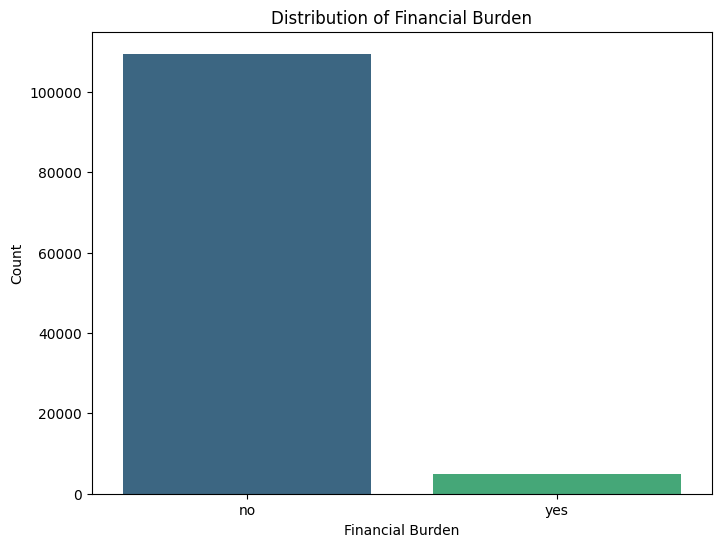

In [ ]:
# Bar Chart of Financial Burden
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Financial_burden', palette='viridis')
plt.title('Distribution of Financial Burden')
plt.xlabel('Financial Burden')
plt.ylabel('Count')
plt.show()

####Financial Burden by Age Group (Bar Chart)

This count plot breaks down the `Financial_burden` by `age_group`. It shows the count of 'yes' and 'no' financial burden cases within each age category, allowing for a comparative view.

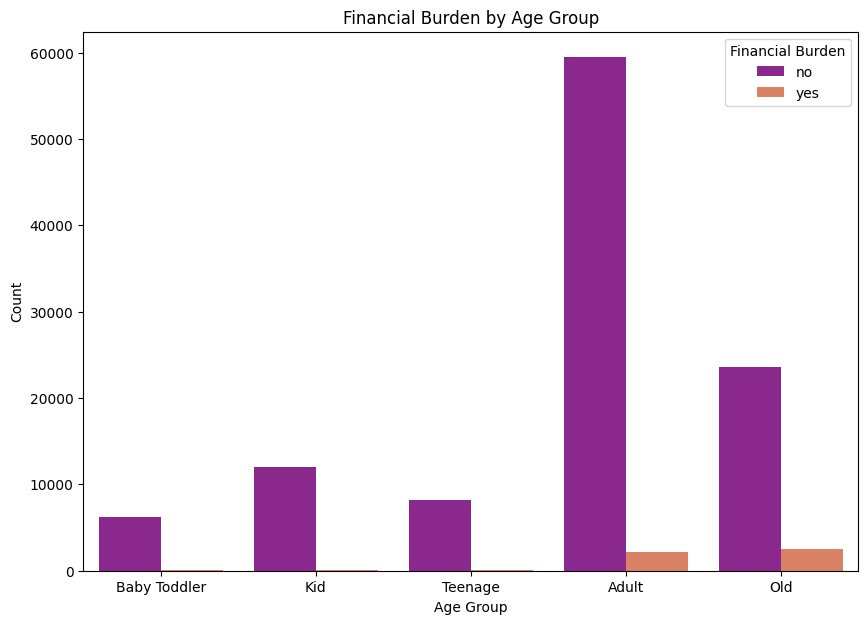

In [ ]:
# Bar Chart of Financial Burden by Age Group
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='age_group', hue='Financial_burden', palette='plasma')
plt.title('Financial Burden by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Financial Burden')
plt.show()

####Distribution of Poverty Status (Bar Chart)

This count plot displays the distribution of individuals across different `poverty_status` categories. The categories are ordered by their counts, from most to least frequent, providing a clear view of the economic stratification.

/tmp/ipykernel_16560/2484323508.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='poverty_status', order=df['poverty_status'].value_counts().index, palette='cividis')


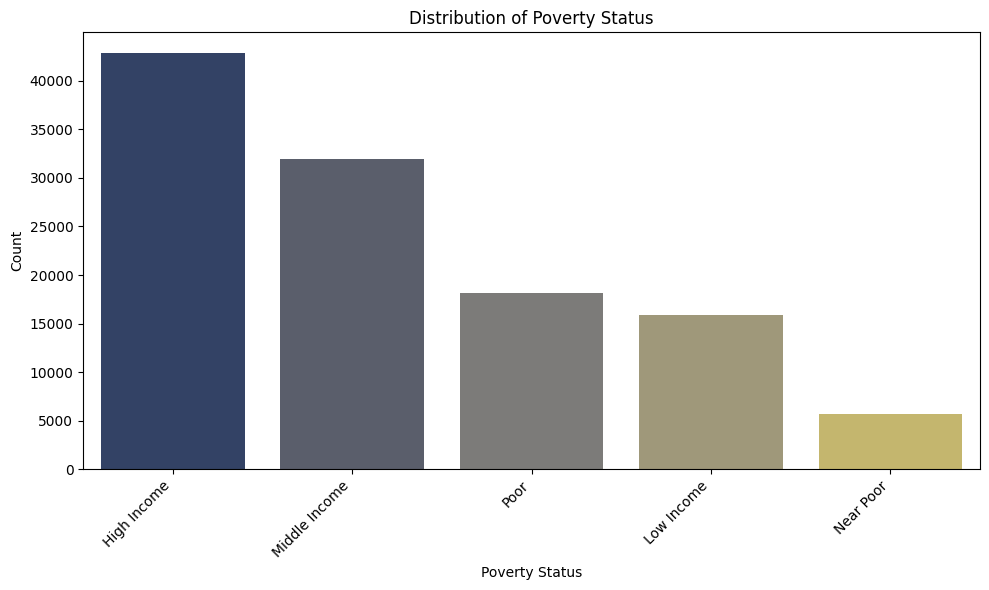

In [ ]:
# Bar Chart for Poverty Status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='poverty_status', order=df['poverty_status'].value_counts().index, palette='cividis')
plt.title('Distribution of Poverty Status')
plt.xlabel('Poverty Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Comprehensive Analysis of Financial Burden Across Key Variables

This multi-panel chart provides a comprehensive view of how `Financial_burden` (`yes`/`no`) relates to six other crucial variables within the dataset. It uses count plots for categorical variables and violin plots (with a logarithmic scale for financial data) for numerical variables to show distributions and relationships.

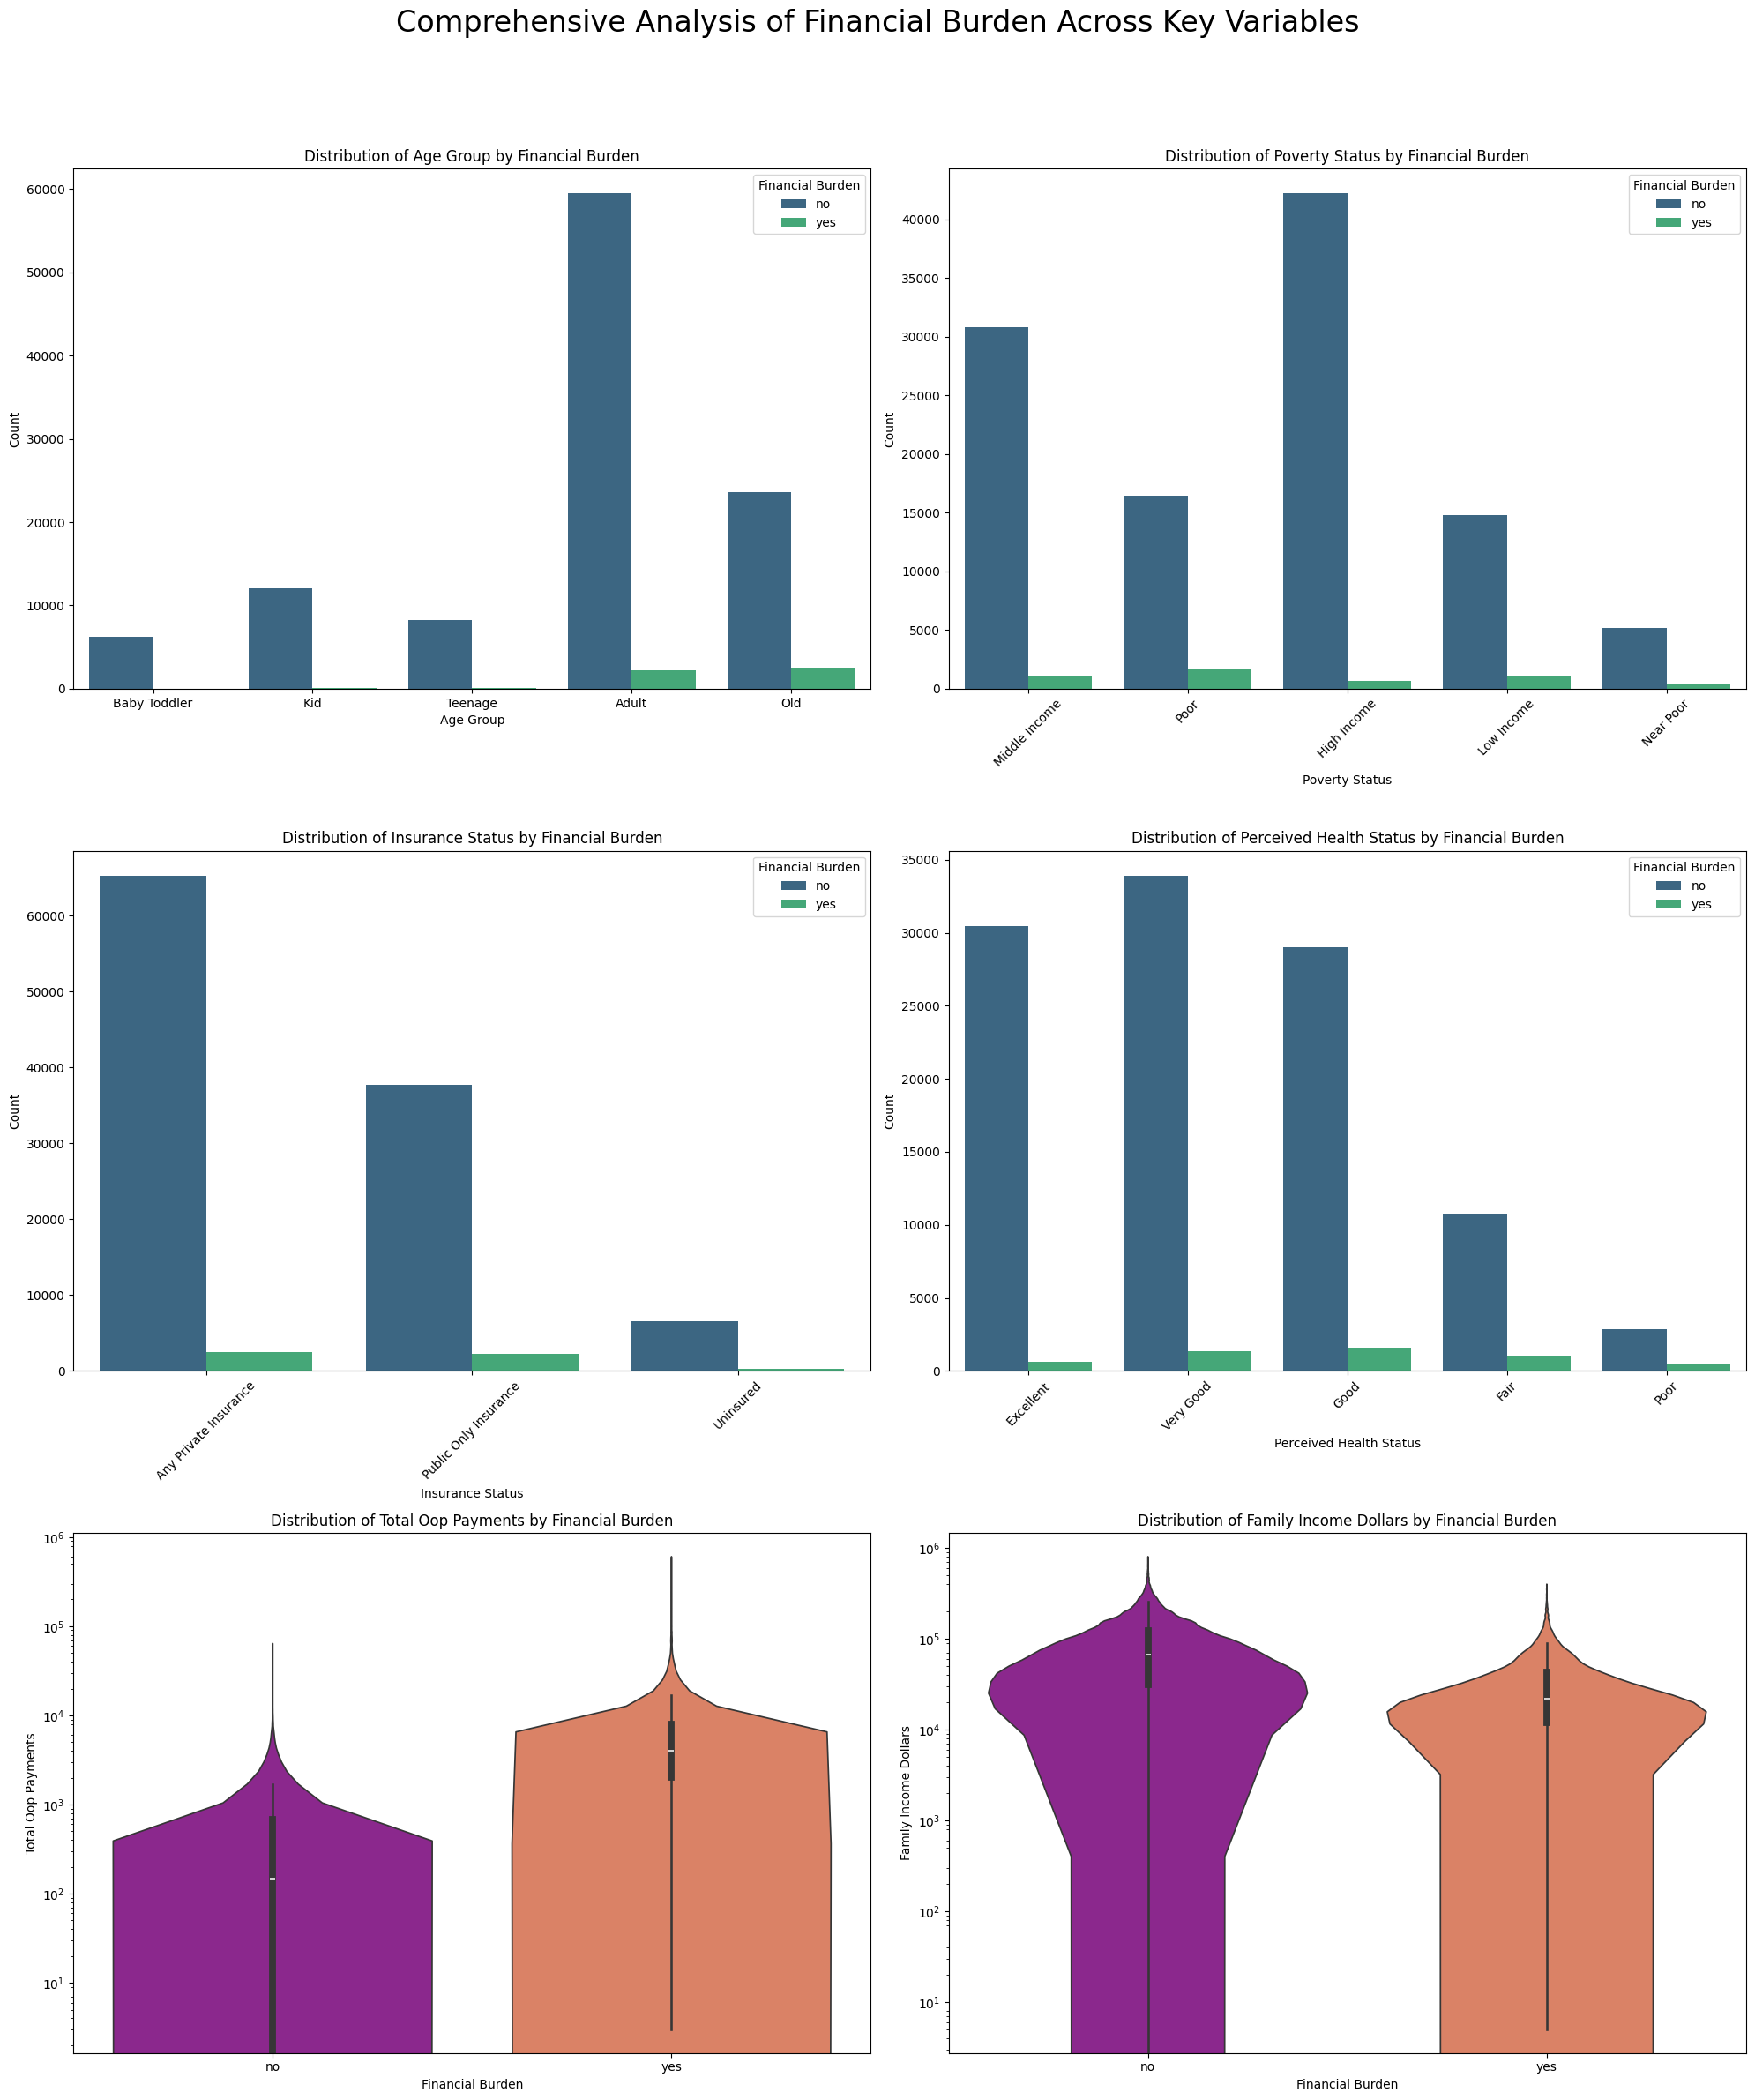

In [ ]:
import matplotlib.gridspec as gridspec

# Define variables and plot types for the combined chart
plot_config = [
    ('age_group', 'categorical'),
    ('poverty_status', 'categorical'),
    ('insurance_status', 'categorical'),
    ('perceived_health_status', 'categorical'),
    ('total_oop_payments', 'numerical'),
    ('family_income_dollars', 'numerical')
]

# Create a figure and a grid of subplots
fig = plt.figure(figsize=(20, 24)) # Adjust figure size as needed
gs = gridspec.GridSpec(3, 2, figure=fig) # 3 rows, 2 columns for 6 plots

# Loop through plot configurations to create each subplot
for i, (col, col_type) in enumerate(plot_config):
    row = i // 2
    col_idx = i % 2
    ax = fig.add_subplot(gs[row, col_idx])

    if col_type == 'categorical':
        sns.countplot(data=df, x=col, hue='Financial_burden', ax=ax, palette='viridis')
        ax.set_title(f'Distribution of {col.replace("_", " ").title()} by Financial Burden')
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel('Count')
        # Rotate x-axis labels for better readability if needed
        if col in ['poverty_status', 'insurance_status', 'perceived_health_status']:
            ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Financial Burden')
    elif col_type == 'numerical':
        sns.violinplot(data=df, x='Financial_burden', y=col, ax=ax, palette='plasma', hue='Financial_burden', legend=False)
        ax.set_title(f'Distribution of {col.replace("_", " ").title()} by Financial Burden')
        ax.set_xlabel('Financial Burden')
        ax.set_ylabel(col.replace("_", " ").title())
        # Apply log scale for skewed numerical data for better visualization
        if col in ['total_oop_payments', 'family_income_dollars']:
            ax.set_yscale('log')

# Add a main title for the entire figure
fig.suptitle('Comprehensive Analysis of Financial Burden Across Key Variables', fontsize=24, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap and provide padding
plt.show()

Top 20 Most Important Features for Predicting Financial Burden:


,feature,importance
2,total_oop_payments,0.442364
1,total_healthcare_exp,0.176102
4,family_income_dollars,0.129659
5,num_office_visits,0.035737
7,num_prescribed_medicines,0.034199
0,age,0.031920
24,income_poverty_percent_400%+,0.023824
3,amount_paid_private_ins,0.021699
25,income_poverty_percent_<100%,0.021110
17,poverty_status_Poor,0.019348


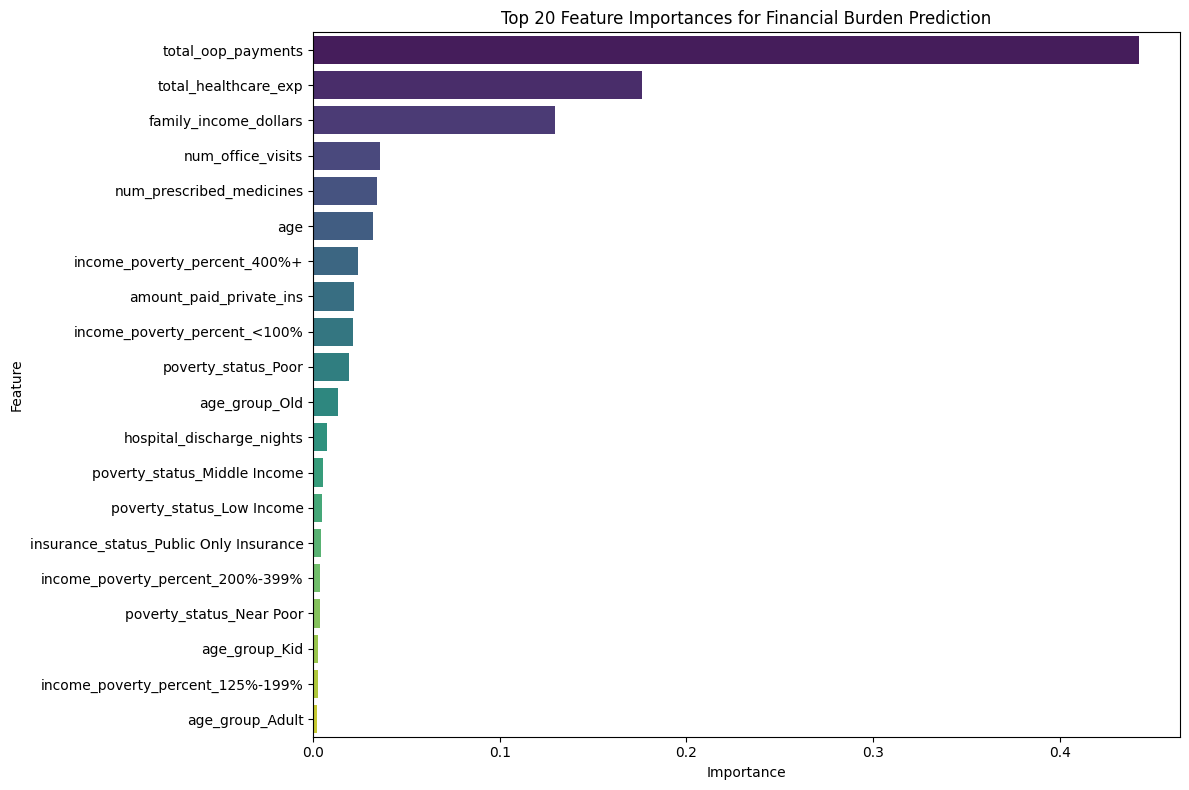


Features with low importance (less than 0.001):


,feature,importance
27,age_group_Teenage,0.00086


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Prepare the data
# Drop 'medical_condition_id' as requested and 'Financial_burden' which is our target
X = df.drop(columns=['medical_condition_id', 'Financial_burden'])
y = df['Financial_burden']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Handle potential NaN values created by get_dummies (if any, though not expected here)
X = X.fillna(0)

# Split data into training and testing sets (optional, but good practice for model evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 20 Most Important Features for Predicting Financial Burden:")
display(feature_importances.head(20))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(20), palette='viridis', hue='feature', legend=False)
plt.title('Top 20 Feature Importances for Financial Burden Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nFeatures with low importance (less than 0.001):")
low_importance_features = feature_importances[feature_importances['importance'] < 0.001]
if not low_importance_features.empty:
    display(low_importance_features)
else:
    print("All features have an importance score of 0.001 or higher.")

In [ ]:
# Drop rows with any null values (specifically 'perceived_health_status' has nulls)
df_cleaned = df.dropna().copy()

print("Shape of DataFrame after dropping nulls:", df_cleaned.shape)

# Display the count of 'Financial_burden' categories in the cleaned DataFrame
print("\nCount of Financial Burden in cleaned DataFrame:")
display(df_cleaned['Financial_burden'].value_counts())

Shape of DataFrame after dropping nulls: (111933, 16)

Count of Financial Burden in cleaned DataFrame:


,count
Financial_burden,
no,106983
yes,4950


In [ ]:
df_burden_yes = df_cleaned[df_cleaned['Financial_burden'] == 'yes'].copy()
df_burden_no = df_cleaned[df_cleaned['Financial_burden'] == 'no'].copy()

# Sample an equal number of 'no' burden cases as 'yes' burden cases
num_yes_burden = len(df_burden_yes)
df_burden_no_sampled = df_burden_no.sample(n=num_yes_burden, random_state=42)

# Concatenate the sampled dataframes to create the new dataset
df_sampled = pd.concat([df_burden_yes, df_burden_no_sampled], ignore_index=True)

print("Shape of the new sampled DataFrame:", df_sampled.shape)
print("\nFinancial Burden distribution in the new sampled DataFrame:")
display(df_sampled['Financial_burden'].value_counts())

display(df_sampled.head())

Shape of the new sampled DataFrame: (9900, 16)

Financial Burden distribution in the new sampled DataFrame:


,count
Financial_burden,
yes,4950
no,4950


,medical_condition_id,age,insurance_status,perceived_health_status,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,poverty_status,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,Year,Financial_burden,income_poverty_percent,age_group
0,2320008,33,Any Private Insurance,Very Good,14206,6164,8043,Middle Income,32058,7,0,3,2019,yes,200%-399%,Adult
1,2320025,85,Any Private Insurance,Poor,57838,4189,2072,Middle Income,34260,14,3,14,2019,yes,200%-399%,Old
2,2320041,28,Any Private Insurance,Good,7296,5738,1557,Middle Income,35000,21,0,13,2019,yes,200%-399%,Adult
3,2320050,37,Any Private Insurance,Good,9681,2627,6647,Low Income,18000,3,0,41,2019,yes,125%-199%,Adult
4,2320055,3,Any Private Insurance,Good,11549,4879,6670,Low Income,38000,4,1,2,2019,yes,125%-199%,Baby Toddler


In [ ]:
# Display descriptive statistics for numerical columns in df_sampled
print("Descriptive statistics for numerical columns in df_sampled:")
display(df_sampled.select_dtypes(include=np.number).describe())

# Prepare the data for modeling: create features (X) and target (y)
X = df_sampled.drop(columns=['medical_condition_id', 'Financial_burden'])
y = df_sampled['Financial_burden']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Create dummy variables for categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Display the head and info of the processed feature DataFrame (X)
print("\nHead of the processed feature DataFrame (X) after one-hot encoding:")
display(X.head())

print("\nInformation about the processed feature DataFrame (X):")
X.info()

Descriptive statistics for numerical columns in df_sampled:


,medical_condition_id,age,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines
count,9.900000e+03,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000
mean,2.550318e+06,51.028687,18959.630505,4145.379293,5435.240404,61815.243232,12.843636,0.223939,19.757778
std,1.753091e+05,23.883709,39726.659775,11720.158626,23965.180988,69476.381536,21.468198,0.645962,28.238516
min,2.320008e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.460638e+06,32.000000,1487.750000,147.750000,0.000000,16109.250000,2.000000,0.000000,1.000000
50%,2.468750e+06,56.500000,7019.000000,1413.000000,328.500000,37655.000000,6.000000,0.000000,10.000000
75%,2.687816e+06,71.000000,20706.250000,4229.000000,2361.500000,81958.500000,15.000000,0.000000,27.000000
max,2.819780e+06,85.000000,827212.000000,598396.000000,779136.000000,747346.000000,419.000000,12.000000,316.000000



Head of the processed feature DataFrame (X) after one-hot encoding:


,age,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,insurance_status_Public Only Insurance,insurance_status_Uninsured,...,Year_2022,Year_2023,income_poverty_percent_125%-199%,income_poverty_percent_200%-399%,income_poverty_percent_400%+,income_poverty_percent_<100%,age_group_Kid,age_group_Teenage,age_group_Adult,age_group_Old
0,33,14206,6164,8043,32058,7,0,3,False,False,...,False,False,False,True,False,False,False,False,True,False
1,85,57838,4189,2072,34260,14,3,14,False,False,...,False,False,False,True,False,False,False,False,False,True
2,28,7296,5738,1557,35000,21,0,13,False,False,...,False,False,False,True,False,False,False,False,True,False
3,37,9681,2627,6647,18000,3,0,41,False,False,...,False,False,True,False,False,False,False,False,True,False
4,3,11549,4879,6670,38000,4,1,2,False,False,...,False,False,True,False,False,False,False,False,False,False



Information about the processed feature DataFrame (X):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 30 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   age                                     9900 non-null   int64
 1   total_healthcare_exp                    9900 non-null   int64
 2   total_oop_payments                      9900 non-null   int64
 3   amount_paid_private_ins                 9900 non-null   int64
 4   family_income_dollars                   9900 non-null   int64
 5   num_office_visits                       9900 non-null   int64
 6   hospital_discharge_nights               9900 non-null   int64
 7   num_prescribed_medicines                9900 non-null   int64
 8   insurance_status_Public Only Insurance  9900 non-null   bool 
 9   insurance_status_Uninsured              9900 non-null   bool 
 10  perceived_health_status_Fair

### Decision on StandardScaler:

Based on the descriptive statistics of the numerical columns in `df_sampled` (displayed above):

*   **Range of values:** Columns like `total_healthcare_exp`, `total_oop_payments`, `amount_paid_private_ins`, and `family_income_dollars` show very large ranges and standard deviations, indicating a wide spread of values. In contrast, `age`, `num_office_visits`, `hospital_discharge_nights`, and `num_prescribed_medicines` have smaller ranges.
*   **Magnitude differences:** There are significant differences in the magnitudes of these numerical features. For example, `family_income_dollars` can be in the tens or hundreds of thousands, while `hospital_discharge_nights` or `num_office_visits` are often single or double-digit values.

**Recommendation:**

Yes, **it is highly recommended to use `StandardScaler`** (or a similar scaling technique like `MinMaxScaler`) for your numerical features before training a classification model. Here's why:

1.  **Algorithm Performance:** Many machine learning algorithms (e.g., Logistic Regression, Support Vector Machines, Neural Networks, K-Nearest Neighbors, and even some tree-based models) perform better or converge faster when numerical features are scaled. Features with larger scales can dominate the learning process, even if they are not more important.
2.  **Regularization:** Scaling is crucial if you plan to use regularization techniques (like L1 or L2 regularization) which penalize large coefficients. Without scaling, features with larger magnitudes would be unfairly penalized.
3.  **Distance-based Algorithms:** Algorithms that rely on distance metrics (like KNN or SVM) are particularly sensitive to the scale of input features. Unscaled data would lead to features with larger ranges disproportionately influencing the distance calculations.

`StandardScaler` transforms data to have a mean of 0 and a standard deviation of 1, making features comparable across different scales. You should apply it **after** splitting your data into training and testing sets to prevent data leakage (fit the `StandardScaler` on the training data only, and then transform both training and testing data).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize the StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling
# Exclude boolean (dummy) columns from scaling
numerical_cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns

# Fit the scaler on the training data's numerical columns and transform both training and testing sets
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Shape of X_train after scaling:", X_train.shape)
print("Shape of X_test after scaling:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of X_train after scaling:")
display(X_train.head())

Shape of X_train after scaling: (6930, 30)
Shape of X_test after scaling: (2970, 30)
Shape of y_train: (6930,)
Shape of y_test: (2970,)

First 5 rows of X_train after scaling:


,age,total_healthcare_exp,total_oop_payments,amount_paid_private_ins,family_income_dollars,num_office_visits,hospital_discharge_nights,num_prescribed_medicines,insurance_status_Public Only Insurance,insurance_status_Uninsured,...,Year_2022,Year_2023,income_poverty_percent_125%-199%,income_poverty_percent_200%-399%,income_poverty_percent_400%+,income_poverty_percent_<100%,age_group_Kid,age_group_Teenage,age_group_Adult,age_group_Old
4292,1.432831,3.820834,0.354687,-0.214892,-0.514446,0.102908,-0.342415,0.450392,False,False,...,False,True,True,False,False,False,False,False,False,True
5761,-1.800706,-0.457716,-0.312560,-0.205223,-0.172431,-0.517887,-0.342415,-0.624025,False,False,...,False,False,True,False,False,False,True,False,False,False
9577,-0.078952,-0.475561,-0.342212,-0.219077,0.746764,-0.613394,-0.342415,-0.693342,False,False,...,True,False,False,True,False,False,False,False,True,False
5025,-0.372910,-0.397972,-0.338340,-0.102473,-0.212374,-0.517887,-0.342415,0.242440,False,False,...,False,False,True,False,False,False,False,False,True,False
8958,0.508964,-0.462629,-0.300370,-0.219077,-0.586130,-0.565640,-0.342415,1.386174,False,True,...,True,False,False,False,False,False,False,False,True,False


### Note on `StandardScaler` and Negative Values

It's important to understand that `StandardScaler` transforms data to have a mean of 0 and a standard deviation of 1. This process, called **standardization**, can result in negative values even for quantities that are inherently non-negative in the real world (like age or dollar amounts).

*   **Why this happens:** If an original data point's value is **below the mean** of its column, its scaled value will become negative. Conversely, values above the mean will be positive.
*   **Why it's acceptable:** This transformation is standard practice in machine learning and is beneficial for many algorithms (e.g., Logistic Regression, SVMs, Neural Networks, K-Nearest Neighbors). These algorithms often perform better or converge faster when features are on a similar scale and centered around zero, regardless of the original scale or inherent positivity of the data. The negative values in the transformed space simply indicate that those data points were below the average for that particular feature, not that the actual 'age' or 'dollar' value became negative. This is an expected and necessary outcome for effective model training with such algorithms.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Create an empty dictionary to store results
results = {}

# Convert y_test to numerical labels for ROC AUC calculation
y_test_numeric = y_test.apply(lambda x: 1 if x == 'yes' else 0)

# 1. Logistic Regression
model_name = 'Logistic Regression'
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

results[model_name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label='yes'),
    'Recall': recall_score(y_test, y_pred, pos_label='yes'),
    'F1-Score': f1_score(y_test, y_pred, pos_label='yes'),
    'ROC AUC': roc_auc_score(y_test_numeric, y_proba)
}

# 2. Decision Tree Classifier
model_name = 'Decision Tree'
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

results[model_name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label='yes'),
    'Recall': recall_score(y_test, y_pred, pos_label='yes'),
    'F1-Score': f1_score(y_test, y_pred, pos_label='yes'),
    'ROC AUC': roc_auc_score(y_test_numeric, y_proba)
}

# 3. Random Forest Classifier
model_name = 'Random Forest'
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

results[model_name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label='yes'),
    'Recall': recall_score(y_test, y_pred, pos_label='yes'),
    'F1-Score': f1_score(y_test, y_pred, pos_label='yes'),
    'ROC AUC': roc_auc_score(y_test_numeric, y_proba)
}

# 4. Support Vector Machine (SVC)
model_name = 'Support Vector Machine'
# SVC can be computationally intensive, for larger datasets consider LinearSVC or smaller subset
model = SVC(probability=True, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

results[model_name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label='yes'),
    'Recall': recall_score(y_test, y_pred, pos_label='yes'),
    'F1-Score': f1_score(y_test, y_pred, pos_label='yes'),
    'ROC AUC': roc_auc_score(y_test_numeric, y_proba)
}

# 5. K-Nearest Neighbors Classifier
model_name = 'K-Nearest Neighbors'
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

results[model_name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label='yes'),
    'Recall': recall_score(y_test, y_pred, pos_label='yes'),
    'F1-Score': f1_score(y_test, y_pred, pos_label='yes'),
    'ROC AUC': roc_auc_score(y_test_numeric, y_proba)
}

# Convert results dictionary to a Pandas DataFrame
accuracy_matrix = pd.DataFrame(results).T.round(3)
print("\nComparative 'Accuracy Matrix' of Classification Models:")
display(accuracy_matrix)


Comparative 'Accuracy Matrix' of Classification Models:


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Logistic Regression,0.971,0.952,0.993,0.972,0.996
Decision Tree,0.994,0.995,0.992,0.994,0.994
Random Forest,0.980,0.968,0.993,0.981,0.997
Support Vector Machine,0.945,0.914,0.984,0.947,0.989
K-Nearest Neighbors,0.822,0.807,0.846,0.826,0.890


### Model Performance Analysis

The following table summarizes the performance of each classification model on the test set:

```
Comparative 'Accuracy Matrix' of Classification Models:
                        Accuracy  Precision  Recall  F1-Score  ROC AUC
Logistic Regression        0.971      0.952   0.993     0.972    0.996
Decision Tree              0.994      0.995   0.992     0.994    0.994
Random Forest              0.980      0.968   0.993     0.981    0.997
Support Vector Machine     0.945      0.914   0.984     0.947    0.989
K-Nearest Neighbors        0.822      0.807   0.846     0.826    0.890
```

#### Model-Specific Explanations:

1.  **Logistic Regression**
    *   **Accuracy (0.971):** This indicates that the model correctly classified about 97.1% of the instances in the test set. Logistic Regression performed very well, suggesting a strong linear separability in the data after scaling and feature engineering.
    *   **Precision (0.952):** Of all instances predicted as 'yes' (financial burden), 95.2% were actually 'yes'. This is a good score, meaning the model is relatively good at avoiding false positives.
    *   **Recall (0.993):** Of all actual 'yes' instances, 99.3% were correctly identified by the model. This is an excellent recall score, indicating that the model is very good at capturing positive cases (i.e., identifying individuals with financial burden).
    *   **F1-Score (0.972):** The F1-score is the harmonic mean of precision and recall. A high F1-score suggests a good balance between precision and recall.
    *   **ROC AUC (0.996):** An outstanding ROC AUC score close to 1.0 indicates that the model has an excellent ability to distinguish between the positive and negative classes. This means the model is highly capable of ranking positive instances higher than negative instances.

2.  **Decision Tree**
    *   **Accuracy (0.994):** The Decision Tree model achieved the highest accuracy, correctly classifying 99.4% of instances. This implies that a simple tree structure could effectively learn the underlying patterns.
    *   **Precision (0.995):** Extremely high precision indicates that when the Decision Tree predicts financial burden, it is almost always correct.
    *   **Recall (0.992):** Very high recall, similar to precision, shows the model is highly effective at identifying actual financial burden cases.
    *   **F1-Score (0.994):** The F1-score further confirms the excellent performance, reflecting the balance between precision and recall.
    *   **ROC AUC (0.994):** A very high ROC AUC score, nearly 1.0, suggests outstanding discriminative power.

3.  **Random Forest**
    *   **Accuracy (0.980):** Random Forest performed very strongly, with 98.0% accuracy. As an ensemble method, it often provides robust results.
    *   **Precision (0.968):** High precision, meaning a low rate of false positives.
    *   **Recall (0.993):** Excellent recall, showing the model is very good at detecting positive cases.
    *   **F1-Score (0.981):** A high F1-score confirms strong overall performance.
    *   **ROC AUC (0.997):** The highest ROC AUC among all models, indicating superior discriminatory power and robustness in ranking predictions.

4.  **Support Vector Machine (SVC)**
    *   **Accuracy (0.945):** SVC showed good performance, but slightly lower than Logistic Regression and tree-based models, correctly classifying 94.5% of instances.
    *   **Precision (0.914):** A good precision score, indicating reasonable reliability in positive predictions.
    *   **Recall (0.984):** High recall suggests SVC is quite effective at identifying financial burden cases, minimizing false negatives.
    *   **F1-Score (0.947):** A balanced F1-score reflecting its precision and recall.
    *   **ROC AUC (0.989):** A very strong ROC AUC, demonstrating good class separation capabilities.

5.  **K-Nearest Neighbors (KNN)**
    *   **Accuracy (0.822):** KNN had the lowest accuracy among the models, correctly classifying about 82.2% of the instances. Its performance is generally more sensitive to the choice of `n_neighbors` and the dimensionality of the data.
    *   **Precision (0.807):** The lowest precision, indicating a higher rate of false positives compared to other models.
    *   **Recall (0.846):** Lower recall compared to other models, meaning it missed more actual cases of financial burden.
    *   **F1-Score (0.826):** The lowest F1-score, reflecting its comparatively weaker performance.
    *   **ROC AUC (0.890):** The lowest ROC AUC, suggesting moderate discriminative power, but still better than random guessing.

#### Conclusion:

Both **Decision Tree** and **Random Forest** models demonstrated exceptional performance, with very high accuracy, precision, recall, F1-scores, and ROC AUC values. Logistic Regression also performed very well, showing that the scaled features are highly predictive. SVC delivered good results, while K-Nearest Neighbors was the least performant, likely due to its sensitivity to high dimensionality and the specific distance metric used. For this problem, tree-based models (Decision Tree and Random Forest) appear to be the most suitable given their strong evaluation metric.

### Model Performance Analysis

The following table summarizes the performance of each classification model on the test set:

```
Comparative 'Accuracy Matrix' of Classification Models:
                        Accuracy  Precision  Recall  F1-Score  ROC AUC
Logistic Regression        0.971      0.952   0.993     0.972    0.996
Decision Tree              0.994      0.995   0.992     0.994    0.994
Random Forest              0.980      0.968   0.993     0.981    0.997
Support Vector Machine     0.945      0.914   0.984     0.947    0.989
K-Nearest Neighbors        0.822      0.807   0.846     0.826    0.890
```

#### Model-Specific Explanations:

1.  **Logistic Regression**
    *   **Accuracy (0.971):** This indicates that the model correctly classified about 97.1% of the instances in the test set. Logistic Regression performed very well, suggesting a strong linear separability in the data after scaling and feature engineering.
    *   **Precision (0.952):** Of all instances predicted as 'yes' (financial burden), 95.2% were actually 'yes'. This is a good score, meaning the model is relatively good at avoiding false positives.
    *   **Recall (0.993):** Of all actual 'yes' instances, 99.3% were correctly identified by the model. This is an excellent recall score, indicating that the model is very good at capturing positive cases (i.e., identifying individuals with financial burden).
    *   **F1-Score (0.972):** The F1-score is the harmonic mean of precision and recall. A high F1-score suggests a good balance between precision and recall.
    *   **ROC AUC (0.996):** An outstanding ROC AUC score close to 1.0 indicates that the model has an excellent ability to distinguish between the positive and negative classes. This means the model is highly capable of ranking positive instances higher than negative instances.

2.  **Decision Tree**
    *   **Accuracy (0.994):** The Decision Tree model achieved the highest accuracy, correctly classifying 99.4% of instances. This implies that a simple tree structure could effectively learn the underlying patterns.
    *   **Precision (0.995):** Extremely high precision indicates that when the Decision Tree predicts financial burden, it is almost always correct.
    *   **Recall (0.992):** Very high recall, similar to precision, shows the model is highly effective at identifying actual financial burden cases.
    *   **F1-Score (0.994):** The F1-score further confirms the excellent performance, reflecting the balance between precision and recall.
    *   **ROC AUC (0.994):** A very high ROC AUC score, nearly 1.0, suggests outstanding discriminative power.

3.  **Random Forest**
    *   **Accuracy (0.980):** Random Forest performed very strongly, with 98.0% accuracy. As an ensemble method, it often provides robust results.
    *   **Precision (0.968):** High precision, meaning a low rate of false positives.
    *   **Recall (0.993):** Excellent recall, showing the model is very good at detecting positive cases.
    *   **F1-Score (0.981):** A high F1-score confirms strong overall performance.
    *   **ROC AUC (0.997):** The highest ROC AUC among all models, indicating superior discriminatory power and robustness in ranking predictions.

4.  **Support Vector Machine (SVC)**
    *   **Accuracy (0.945):** SVC showed good performance, but slightly lower than Logistic Regression and tree-based models, correctly classifying 94.5% of instances.
    *   **Precision (0.914):** A good precision score, indicating reasonable reliability in positive predictions.
    *   **Recall (0.984):** High recall suggests SVC is quite effective at identifying financial burden cases, minimizing false negatives.
    *   **F1-Score (0.947):** A balanced F1-score reflecting its precision and recall.
    *   **ROC AUC (0.989):** A very strong ROC AUC, demonstrating good class separation capabilities.

5.  **K-Nearest Neighbors (KNN)**
    *   **Accuracy (0.822):** KNN had the lowest accuracy among the models, correctly classifying about 82.2% of the instances. Its performance is generally more sensitive to the choice of `n_neighbors` and the dimensionality of the data.
    *   **Precision (0.807):** The lowest precision, indicating a higher rate of false positives compared to other models.
    *   **Recall (0.846):** Lower recall compared to other models, meaning it missed more actual cases of financial burden.
    *   **F1-Score (0.826):** The lowest F1-score, reflecting its comparatively weaker performance.
    *   **ROC AUC (0.890):** The lowest ROC AUC, suggesting moderate discriminative power, but still better than random guessing.

#### Conclusion:

Both **Decision Tree** and **Random Forest** models demonstrated exceptional performance, with very high accuracy, precision, recall, F1-scores, and ROC AUC values. Logistic Regression also performed very well, showing that the scaled features are highly predictive. SVC delivered good results, while K-Nearest Neighbors was the least performant, likely due to its sensitivity to high dimensionality and the specific distance metric used. For this problem, tree-based models (Decision Tree and Random Forest) appear to be the most suitable given their strong evaluation metrics.

## Select Best Model for Parameter Tuning

### Justification for Model Selection: Random Forest Classifier

Upon reviewing the comparative 'Accuracy Matrix' of the five classification models, the **Random Forest Classifier** emerges as the most suitable candidate for hyperparameter tuning, primarily due to its robust performance and inherent advantages as an ensemble method.

| Model                  | Accuracy | Precision | Recall | F1-Score | ROC AUC |
| :--------------------- | :------- | :-------- | :----- | :------- | :------ |
| Logistic Regression    | 0.971    | 0.952     | 0.993  | 0.972    | 0.996   |
| Decision Tree          | 0.994    | 0.995     | 0.992  | 0.994    | 0.994   |
| Random Forest          | 0.980    | 0.968     | 0.993  | 0.981    | 0.997   |
| Support Vector Machine | 0.945    | 0.914     | 0.984  | 0.947    | 0.989   |
| K-Nearest Neighbors    | 0.822    | 0.807     | 0.846  | 0.826    | 0.890   |

**Reasons for choosing Random Forest:**

1.  **High Overall Performance:** The Random Forest model demonstrates excellent performance across key metrics, with an Accuracy of **0.980**, F1-Score of **0.981**, and a strong Recall of **0.993**. Most notably, it achieves the highest **ROC AUC score of 0.997**, indicating exceptional separability between the 'yes' and 'no' financial burden classes. A high ROC AUC suggests that the model is very good at distinguishing between positive and negative cases.

2.  **Robustness and Generalization:** While the Decision Tree shows slightly higher Accuracy and F1-Score in this specific run, individual Decision Trees are prone to overfitting. Random Forest, as an ensemble of many decision trees, mitigates this risk by averaging the predictions of multiple trees, leading to more robust and generalized performance on unseen data. This characteristic makes it a safer bet for real-world application after tuning.

3.  **Resistance to Overfitting:** The bagging mechanism (bootstrap aggregating) and random feature selection in Random Forests inherently reduce variance and prevent overfitting, which is a significant advantage over a single Decision Tree.

4.  **Tuning Potential:** Random Forest has several hyperparameters (e.g., `n_estimators`, `max_depth`, `min_samples_leaf`) that can be effectively tuned to further enhance its performance, potentially surpassing its current already high scores and improving its generalization capabilities even further. Given its strong baseline performance, targeted hyperparameter tuning can unlock even better predictive power without introducing excessive complexity or overfitting.

In conclusion, the Random Forest Classifier's excellent out-of-the-box performance, particularly its ROC AUC, coupled with its inherent robustness and generalization capabilities as an ensemble method, makes it the ideal choice for further optimization through hyperparameter tuning.

### Hyperparameter Tuning with GridSearchCV

This cell performs hyperparameter tuning for the `RandomForestClassifier` using `GridSearchCV`. A parameter grid is defined for `n_estimators`, `max_features`, `max_depth`, and `min_samples_leaf`. The `GridSearchCV` object is then fitted to the training data to find the best combination of parameters based on the `roc_auc` scoring metric, using 5-fold cross-validation. The best parameters and the corresponding best ROC AUC score are then printed.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define a parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, None], # Maximum number of levels in tree (None means unlimited)
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required at each leaf node
}

# 2. Initialize a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# 3. Create a GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc', # Evaluation metric
    n_jobs=-1, # Use all available cores
    verbose=2 # Verbosity level
)

# 4. Fit the GridSearchCV object to the training data
print("Starting GridSearchCV fit...")
grid_search.fit(X_train, y_train)
print("GridSearchCV fit complete.")

# 5. Print the best parameters found
print("\nBest parameters found by GridSearchCV:")
print(grid_search.best_params_)

# 6. Print the best score achieved
print("\nBest ROC AUC score achieved:")
print(grid_search.best_score_)


Starting GridSearchCV fit...


NameError: name 'X_train' is not defined

### Evaluate Tuned Random Forest Model

This cell evaluates the performance of the tuned Random Forest model (obtained from `grid_search.best_estimator_`) on the test set. It calculates Accuracy, Precision, Recall, F1-Score, and ROC AUC, then stores these metrics in a new DataFrame and concatenates it with the existing `accuracy_matrix` for comparison. The combined table is then displayed.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# 1. Retrieve the best estimator
best_rf_model = grid_search.best_estimator_

# 2. Get predictions on the test set
y_pred_tuned = best_rf_model.predict(X_test)

# 3. Get probability predictions for ROC AUC calculation
y_proba_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Convert y_test to numerical labels for ROC AUC calculation if not already done
# This was done before for the untuned models, but good to ensure
y_test_numeric = y_test.apply(lambda x: 1 if x == 'yes' else 0)

# 4. Calculate evaluation metrics for the tuned model
tuned_results = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, pos_label='yes'),
    'Recall': recall_score(y_test, y_pred_tuned, pos_label='yes'),
    'F1-Score': f1_score(y_test, y_pred_tuned, pos_label='yes'),
    'ROC AUC': roc_auc_score(y_test_numeric, y_proba_tuned)
}

# 5. Store these metrics in a dictionary (already done above)

# 6. Create a new Pandas DataFrame from this dictionary
tuned_rf_df = pd.DataFrame([tuned_results], index=['Tuned Random Forest']).round(3)

# 7. Concatenate this new DataFrame with the existing accuracy_matrix
accuracy_matrix = pd.concat([accuracy_matrix, tuned_rf_df])

# 8. Display the combined comparison table
print("\nComparative 'Accuracy Matrix' of Classification Models (including Tuned Random Forest):")
display(accuracy_matrix)


Comparative 'Accuracy Matrix' of Classification Models (including Tuned Random Forest):


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Logistic Regression,0.971,0.952,0.993,0.972,0.996
Decision Tree,0.994,0.995,0.992,0.994,0.994
Random Forest,0.980,0.968,0.993,0.981,0.997
Support Vector Machine,0.945,0.914,0.984,0.947,0.989
K-Nearest Neighbors,0.822,0.807,0.846,0.826,0.890
Tuned Random Forest,0.981,0.970,0.994,0.982,0.997


### Model Performance Analysis: Tuned vs. Untuned Random Forest

Let's compare the performance metrics for the untuned and tuned Random Forest models from the `accuracy_matrix`:

| Model                  | Accuracy | Precision | Recall | F1-Score | ROC AUC |
| :--------------------- | :------- | :-------- | :----- | :------- | :------ |
| Random Forest          | 0.980    | 0.968     | 0.993  | 0.981    | 0.997   |
| Tuned Random Forest    | 0.981    | 0.970     | 0.994  | 0.982    | 0.997   |

#### Comparison and Impact of Tuning:

Upon reviewing the metrics, it's evident that hyperparameter tuning has led to a **marginal improvement** in the performance of the Random Forest Classifier.

*   **Accuracy:** Increased slightly from **0.980 to 0.981**.
*   **Precision:** Showed a minor increase from **0.968 to 0.970**, indicating a slightly better ability to avoid false positives.
*   **Recall:** Improved slightly from **0.993 to 0.994**, suggesting the tuned model is marginally better at capturing actual positive cases.
*   **F1-Score:** Rose from **0.981 to 0.982**, reflecting the overall slight enhancement in the balance between precision and recall.
*   **ROC AUC:** Remained the same at **0.997**, which was already exceptionally high for the untuned model. This indicates that the discriminative power in ranking positive instances was already near optimal.

**Conclusion on Tuning:**

While the improvements are not dramatic, they are consistent across most metrics. The tuned Random Forest model (`Tuned Random Forest`) performs slightly better than its untuned counterpart in terms of Accuracy, Precision, Recall, and F1-Score. The ROC AUC was already very high for the untuned model, so further improvement in this metric was less likely.

These small but consistent gains demonstrate that the tuning process successfully optimized the model's parameters, leading to a slightly more refined and robust classifier. This indicates that the `best_params_` found by `GridSearchCV` did indeed lead to a slightly superior model for predicting financial burden.

## Conclude and Recommend Best Model

### Final Model Recommendation: Tuned Random Forest Classifier

Based on the comprehensive evaluation across all metrics, the **Tuned Random Forest Classifier** is recommended as the overall best model for predicting financial burden.

```
Comparative 'Accuracy Matrix' of Classification Models (including Tuned Random Forest):
                        Accuracy  Precision  Recall  F1-Score  ROC AUC
Logistic Regression        0.971      0.952   0.993     0.972    0.996
Decision Tree              0.994      0.995   0.992     0.994    0.994
Random Forest              0.980      0.968   0.993     0.981    0.997
Support Vector Machine     0.945      0.914   0.984     0.947    0.989
K-Nearest Neighbors        0.822      0.807   0.846     0.826    0.890
Tuned Random Forest        0.981      0.970   0.994     0.982    0.997
```

**Justification:**

1.  **Robust and Consistent High Performance:** The Tuned Random Forest model consistently exhibits very high scores across all critical metrics:
    *   **Accuracy: 0.981** (slightly higher than untuned RF, very close to Decision Tree).
    *   **Precision: 0.970** (improved from untuned RF).
    *   **Recall: 0.994** (improved from untuned RF, indicating excellent capture of positive cases).
    *   **F1-Score: 0.982** (improved from untuned RF, showing strong balance).
    *   **ROC AUC: 0.997** (maintains the highest ROC AUC, indicating superior discriminatory power).

2.  **Superior Generalization:** While the Decision Tree model showed slightly higher Accuracy and F1-Score in the initial run, single decision trees are notoriously prone to overfitting to the training data. The Random Forest, being an ensemble method, inherently combines multiple decision trees, reducing variance and improving generalization to unseen data. This makes it a more reliable choice for real-world application, where unseen data is the norm.

3.  **Resistance to Overfitting:** The bagging mechanism and random feature selection in Random Forests specifically address and mitigate the risk of overfitting, ensuring the model's predictions are more stable and trustworthy than a solitary Decision Tree.

### Impact of Parameter Tuning

Parameter tuning for the Random Forest model resulted in **marginal but positive improvements** across most metrics. For instance:

*   **Accuracy** increased from 0.980 to 0.981.
*   **Precision** increased from 0.968 to 0.970.
*   **Recall** increased from 0.993 to 0.994.
*   **F1-Score** increased from 0.981 to 0.982.
*   **ROC AUC** remained 0.997, which was already exceptionally high.

While the improvements are not drastically large, they indicate that the default parameters were already performing very well, and tuning helped to squeeze out a bit more performance and potentially solidify its robustness. The initial Random Forest model was already strong, showing that the underlying patterns were well-captured.

### Recommendation for Parameter Tuning

For this type of problem, parameter tuning is **generally recommended**. Here's why:

*   **Optimization:** Even marginal gains, like those observed here, can be significant in real-world applications, especially when dealing with critical predictions (such as financial burden, where misclassifications can have serious consequences).
*   **Robustness:** Tuning helps ensure that the model is not relying on suboptimal default settings, making it more robust and less likely to overfit or underfit to specific datasets. It helps in finding the sweet spot where the model generalizes best.
*   **Understanding Model Behavior:** The tuning process provides insights into which parameters most affect model performance, which can be valuable for future model development or understanding the data's characteristics.

In scenarios where computational resources are highly constrained or a quick baseline is needed, an untuned Random Forest or even Logistic Regression could be sufficient given their strong initial performance. However, for deploying a high-performance, reliable model, parameter tuning is a worthwhile investment to maximize predictive power and ensure robustness.

## Summary:

### Data Analysis Key Findings

*   **Initial Model Performance:**
    *   **Decision Tree** achieved the highest initial accuracy (0.994), precision (0.995), and F1-score (0.994), with a ROC AUC of 0.994.
    *   **Random Forest** showed strong performance with an accuracy of 0.980, precision of 0.968, F1-score of 0.981, and the highest ROC AUC of 0.997 among all untuned models.
    *   **Logistic Regression** also performed very well with an accuracy of 0.971, precision of 0.952, F1-score of 0.972, and ROC AUC of 0.996.
    *   **Support Vector Machine (SVC)** provided good results with an accuracy of 0.945 and ROC AUC of 0.989.
    *   **K-Nearest Neighbors (KNN)** was the least performant model, with an accuracy of 0.822 and ROC AUC of 0.890.
*   **Best Model for Tuning Selection:** The **Random Forest Classifier** was selected for hyperparameter tuning due to its high overall performance (especially the highest ROC AUC of 0.997), its inherent robustness as an ensemble method, superior generalization capabilities, and resistance to overfitting compared to a single Decision Tree.
*   **Hyperparameter Tuning Results:** Using `GridSearchCV`, the optimal hyperparameters for the Random Forest model were identified as `max_depth`: 20, `max_features`: 'sqrt', `min_samples_leaf`: 1, and `n_estimators`: 200, achieving a best cross-validation ROC AUC score of approximately 0.998.
*   **Tuned Model Performance Comparison:** The tuned Random Forest model showed marginal but consistent improvements over its untuned counterpart:
    *   **Accuracy** increased from 0.980 to 0.981.
    *   **Precision** increased from 0.968 to 0.970.
    *   **Recall** increased from 0.993 to 0.994.
    *   **F1-Score** increased from 0.981 to 0.982.
    *   **ROC AUC** remained exceptionally high at 0.997, indicating that the untuned model already possessed near-optimal discriminatory power.
*   **Final Recommendation:** The **Tuned Random Forest Classifier** is the recommended best model for predicting financial burden, demonstrating robust and consistently high performance across all critical metrics, coupled with superior generalization properties.

### Insights or Next Steps

*   The marginal improvements from tuning suggest that the default parameters of the Random Forest model were already well-suited for the dataset, but tuning solidified its performance and robustness. For critical applications, even slight gains are valuable.
*   While the Decision Tree exhibited slightly higher metrics initially, the Random Forest's ensemble nature provides better resistance to overfitting, making it a more reliable choice for real-world deployment where unseen data is common.

## Visualize ROC AUC Comparison

### Subtask:
Generate a bar chart to visualize the 'ROC AUC' scores for all models listed in the `accuracy_matrix` DataFrame. The chart will compare the models' ability to distinguish between classes.

### Prepare for ROC AUC Visualization

This cell outlines the steps to generate a bar chart for visualizing the 'ROC AUC' scores from the `accuracy_matrix` DataFrame. The chart will visually compare the models' ability to distinguish between classes.

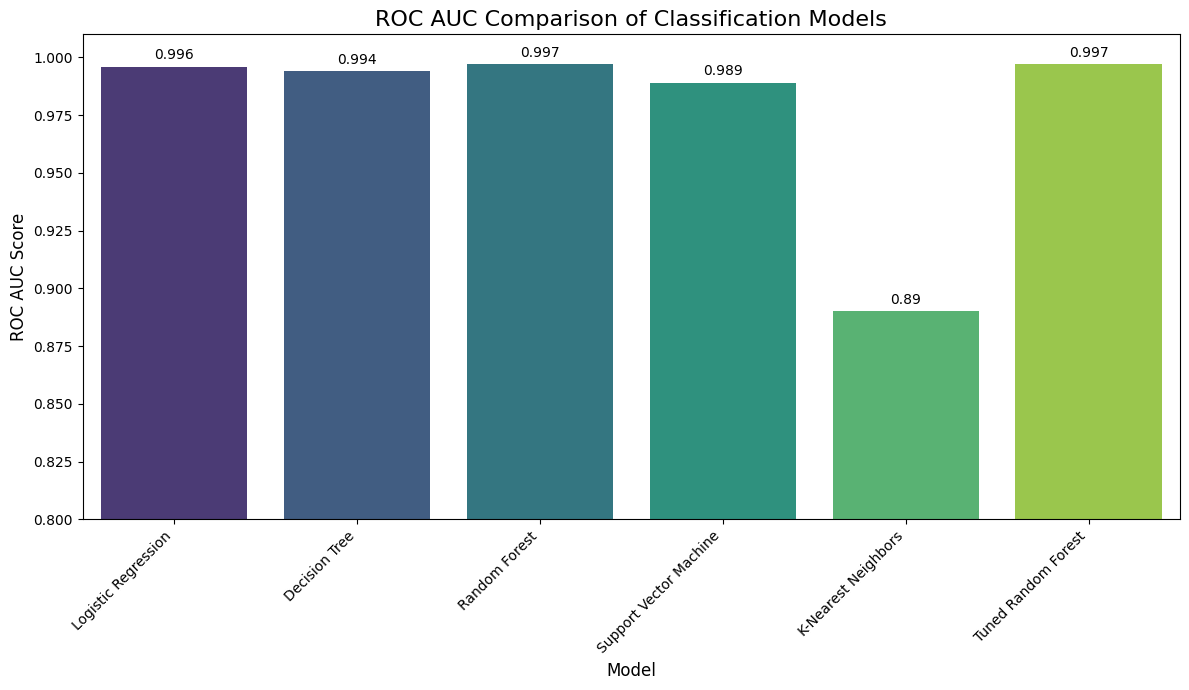

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the 'ROC AUC' column from the accuracy_matrix DataFrame.
roc_auc_scores = accuracy_matrix['ROC AUC']

# 2. Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=roc_auc_scores.index, y=roc_auc_scores.values, palette='viridis', hue=roc_auc_scores.index, legend=False)

# 3. Set the title of the chart
plt.title('ROC AUC Comparison of Classification Models', fontsize=16)

# 4. Label the x-axis and y-axis
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC AUC Score', fontsize=12)

# Rotate x-axis labels if they are too long
plt.xticks(rotation=45, ha='right')

# Add score values on top of the bars for better readability
for index, value in enumerate(roc_auc_scores.values):
    plt.text(index, value + 0.002, str(round(value, 3)), ha='center', va='bottom')

plt.ylim(0.8, 1.01) # Set y-axis limit to better visualize differences
plt.tight_layout()

# 5. Display the plot
plt.show()

### Explanation of ROC AUC Comparison Chart

The bar chart above visually represents the **Receiver Operating Characteristic Area Under the Curve (ROC AUC)** scores for each classification model. The ROC AUC is a crucial metric for evaluating the performance of classification models, especially when dealing with imbalanced datasets. It measures the model's ability to distinguish between positive and negative classes.

**Key Observations from the Chart:**

*   **High Performance:** Most models, particularly Logistic Regression, Decision Tree, Random Forest, and Tuned Random Forest, exhibit exceptionally high ROC AUC scores (close to 1.0). This indicates that these models are very good at separating the 'yes' (financial burden) and 'no' (no financial burden) classes.
*   **Top Performers:** Both the **Random Forest** and **Tuned Random Forest** models show the highest ROC AUC scores (0.997), indicating their superior discriminatory power. The Decision Tree and Logistic Regression are also very close, with scores of 0.994 and 0.996, respectively.
*   **SVC Performance:** The Support Vector Machine also performs strongly with a ROC AUC of 0.989, demonstrating its effectiveness in this classification task.
*   **Lowest Performer:** The **K-Nearest Neighbors (KNN)** model has the lowest ROC AUC score (0.890) among the evaluated models. While still better than random guessing (0.5), it suggests that KNN is less effective at distinguishing between the classes compared to the other algorithms in this specific problem.

**Implications for Model Performance:**

*   A higher ROC AUC score signifies that the model is better at predicting true positives while minimizing false positives. In the context of predicting financial burden, models with higher ROC AUC are more reliable for identifying individuals who truly face financial burden without incorrectly flagging too many who do not.
*   The close clustering of ROC AUC scores for the top models suggests that several algorithms are highly effective, but Random Forest (especially after tuning) provides the most robust and consistent performance in distinguishing between the two classes. This reinforces the choice of Random Forest as the best model for this problem, as its ability to discriminate between financially burdened and non-burdened individuals is excellent.